Training and Testing XGBoost because tf-idf matrix is A LOT and random forest is not good for that!

Also doing a grid search to find optimal parameters for XGBoost before moving on to applying the model to trained data.

Also using SVD to reduce the dimensionality of the tf-idf matrix

Additionally, want to state that RECALL is the metric I will focus on not accuracy because out of these two possibilities:
- Flag a legitimate job posting as suspicious (false positive)
- Miss a fraudulent job and let users get scammed (false negative)
The second is more important. 

Additionally, instead of ROC-AUC, using PR-AUC is better since fraud is very rare. 
- High PR–AUC = consistently good fraud detection even at different probability cutoffs.
- PR-AUC answers: “Across all classification thresholds, how well does the model trade off precision and recall for the fraud class?”

In [1]:
import joblib
import numpy as np
import os
from scipy import sparse
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

In [2]:
print("Loading saved engineered data...")

# === LOAD SAVED MATRICES ===
tfidf = joblib.load("../feature_engineering/tfidf_vectorizer.pkl")

X_train = joblib.load("../feature_engineering/X_train.pkl")
X_test  = joblib.load("../feature_engineering/X_test.pkl")

X_train_tfidf = joblib.load("../feature_engineering/X_train_tfidf.pkl")
X_test_tfidf  = joblib.load("../feature_engineering/X_test_tfidf.pkl")

y_train = joblib.load("../feature_engineering/y_train.pkl")
y_test  = joblib.load("../feature_engineering/y_test.pkl")

print("Data loaded successfully.\n")

Loading saved engineered data...
Data loaded successfully.



In [3]:
X_train_tfidf.shape

(17889, 10000)

In [4]:

# === Convert booleans to numeric for sparse matrix ===
def to_numeric_sparse(df):
    df = df.copy()
    bool_cols = df.select_dtypes(include="bool").columns.tolist()
    if bool_cols:
        df[bool_cols] = df[bool_cols].astype(np.int8)
    return sparse.csr_matrix(df.values), df.columns.to_numpy()

X_train_struct_sparse, struct_columns = to_numeric_sparse(X_train)
X_test_struct_sparse, _ = to_numeric_sparse(X_test)

# === Combine matrices ===
X_train_combined = sparse.hstack([X_train_tfidf, X_train_struct_sparse])
X_test_combined  = sparse.hstack([X_test_tfidf,  X_test_struct_sparse])

print("Final train shape:", X_train_combined.shape)
print("Final test shape :", X_test_combined.shape, "\n")


Final train shape: (17889, 10019)
Final test shape : (7667, 10019) 



In [5]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

# ================== 1. Apply SVD to TF-IDF ==================

n_svd_components = 300  # adjust as needed
svd = TruncatedSVD(n_components=n_svd_components, random_state=42)

X_train_tfidf_svd = svd.fit_transform(X_train_tfidf)
X_test_tfidf_svd  = svd.transform(X_test_tfidf)

print("TF-IDF reduced via SVD:")
print("Train shape:", X_train_tfidf_svd.shape)
print("Test shape :", X_test_tfidf_svd.shape)

# ================== 2. Scale Structured Features ==================

scaler = StandardScaler(with_mean=False)  # with_mean=False for sparse matrices
X_train_struct_scaled = scaler.fit_transform(X_train_struct_sparse)
X_test_struct_scaled  = scaler.transform(X_test_struct_sparse)

# ================== 3. Combine SVD + Structured Features ==================

from scipy.sparse import hstack, csr_matrix

# Convert dense SVD output to sparse before stacking (optional, XGBoost handles dense too)
X_train_svd_sparse = csr_matrix(X_train_tfidf_svd)
X_test_svd_sparse  = csr_matrix(X_test_tfidf_svd)

X_train_combined = hstack([X_train_svd_sparse, X_train_struct_scaled])
X_test_combined  = hstack([X_test_svd_sparse,  X_test_struct_scaled])

print("Final combined shapes:")
print("X_train_combined:", X_train_combined.shape)
print("X_test_combined :", X_test_combined.shape)

joblib.dump(svd, "tfidf_svd.pkl")

TF-IDF reduced via SVD:
Train shape: (17889, 300)
Test shape : (7667, 300)
Final combined shapes:
X_train_combined: (17889, 319)
X_test_combined : (7667, 319)


['tfidf_svd.pkl']

In [6]:
#saving updated X_train and X_test for future modeling:
joblib.dump(X_train_combined, "X_TRAIN_COMBINED_FINAL_SVD")
joblib.dump(X_test_combined, "X_TEST_COMBINED_FINAL_SVD")

['X_TEST_COMBINED_FINAL_SVD']

In [7]:
# ======================   XGBOOST MODEL DEFINITION ========================================

xgb = XGBClassifier(
    n_estimators=350,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    tree_method="hist",          # FAST + supports sparse matrices well
    n_jobs=-1,
    random_state=42
)


# =====================================================================================
#                           CROSS VALIDATION
# =====================================================================================

print("Running 5-fold stratified cross-validation (Recall and PR-AUC)...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Recall (fraud class)
cv_recall = cross_val_score(xgb, X_train_combined, y_train, cv=cv, scoring="recall")

# PR-AUC (Average Precision Score)
cv_pr_auc = cross_val_score(xgb, X_train_combined, y_train, cv=cv, scoring="average_precision")

print("\nRecall scores:", cv_recall)
print(f"Mean Recall: {cv_recall.mean():.4f} | Std: {cv_recall.std():.4f}\n")

print("PR-AUC scores:", cv_pr_auc)
print(f"Mean PR-AUC: {cv_pr_auc.mean():.4f} | Std: {cv_pr_auc.std():.4f}\n")


# =====================================================================================
#                           TRAIN FINAL MODEL
# =====================================================================================

print("Training final XGBoost model...")

xgb.fit(
    X_train_combined, y_train,
    eval_set=[(X_train_combined, y_train), (X_test_combined, y_test)],
    verbose=False
)

print("Model trained.\n")


# =====================================================================================
#                              EVALUATE MODEL
# =====================================================================================

print("Evaluating on held-out test set...\n")
y_pred = xgb.predict(X_test_combined)

print("Test Accuracy:", accuracy_score(y_test, y_pred), "\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("XGBoost – Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("xgb_confusion_matrix.png")
plt.close()
print("Confusion matrix saved as xgb_confusion_matrix.png\n")


# ================  FEATURE IMPORTANCES ===================================

print("Extracting feature importances...")

importances = xgb.feature_importances_
n_tfidf = X_train_tfidf.shape[1]

text_importances = importances[:n_tfidf]
struct_importances = importances[n_tfidf:]

feature_names_text = tfidf.get_feature_names_out()
top_text_idx = np.argsort(text_importances)[-25:][::-1]

print("\nTop TF-IDF Keywords Indicating Fraud:")
for idx in top_text_idx:
    print(f"- {feature_names_text[idx]} ({text_importances[idx]:.6f})")

top_struct_idx = np.argsort(struct_importances)[-15:][::-1]

print("\nTop Structured Features:")
for idx in top_struct_idx:
    print(f"- {struct_columns[idx]} ({struct_importances[idx]:.6f})")



# ==================== SAVE FINAL MODEL===========================================

joblib.dump(xgb, "xgboost_all_features.pkl")
print("\nModel saved as xgboost_all_features.pkl")


Running 5-fold stratified cross-validation (Recall and PR-AUC)...

Recall scores: [0.96858289 0.96657754 0.96524064 0.96858289 0.96724599]
Mean Recall: 0.9672 | Std: 0.0013

PR-AUC scores: [0.99670653 0.99782216 0.99777448 0.9980189  0.99799572]
Mean PR-AUC: 0.9977 | Std: 0.0005

Training final XGBoost model...
Model trained.

Evaluating on held-out test set...

Test Accuracy: 0.9842180774748924 

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      4461
           1       1.00      0.96      0.98      3206

    accuracy                           0.98      7667
   macro avg       0.99      0.98      0.98      7667
weighted avg       0.98      0.98      0.98      7667

Confusion matrix saved as xgb_confusion_matrix.png

Extracting feature importances...

Top TF-IDF Keywords Indicating Fraud:
- 00 (0.389677)
- 00 00 (0.050763)
- accurate (0.013560)
- acquired (0.011334)
- 00am (0.010529)
- accurate timely (0.009774

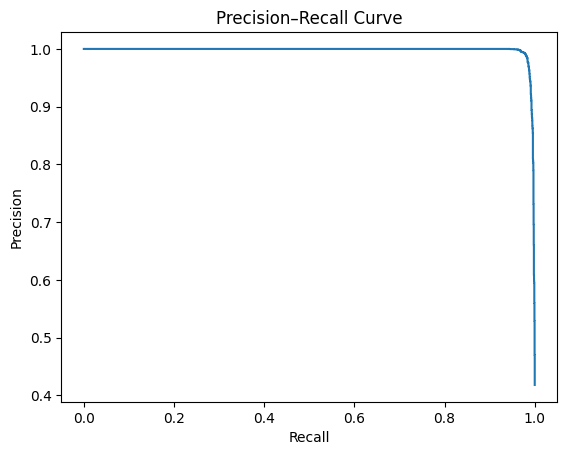

In [8]:
import matplotlib.pyplot as plt

y_scores = xgb.predict_proba(X_test_combined)[:, 1]   # probability of fraud

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()


In [9]:
from sklearn.model_selection import RandomizedSearchCV

In [10]:
# ====================  RANDOMIZED SEARCH PARAMETER GRID ==============================

param_dist = {
    "n_estimators": [200, 350, 500, 700],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.5, 0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.2, 0.4],
}



# Randomized search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,               # try 30 combos
    scoring="average_precision", #using PR-AUC to pick best model
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("\nRunning Randomized Search CV...")
random_search.fit(X_train_combined, y_train)

print("\n=====================")
print(" BEST PARAMETERS")
print("=====================")
print(random_search.best_params_)

print("\nBest PR-AUC Score:", random_search.best_score_)


Running Randomized Search CV...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


[CV] END colsample_bytree=1.0, gamma=0.4, learning_rate=0.05, max_depth=8, min_child_weight=7, n_estimators=200, subsample=1.0; total time=  10.5s
[CV] END colsample_bytree=1.0, gamma=0.4, learning_rate=0.05, max_depth=8, min_child_weight=7, n_estimators=200, subsample=1.0; total time=  10.5s
[CV] END colsample_bytree=1.0, gamma=0.4, learning_rate=0.05, max_depth=8, min_child_weight=7, n_estimators=200, subsample=1.0; total time=  11.1s
[CV] END colsample_bytree=0.7, gamma=0.4, learning_rate=0.01, max_depth=6, min_child_weight=5, n_estimators=350, subsample=0.8; total time=  14.3s
[CV] END colsample_bytree=0.7, gamma=0.4, learning_rate=0.01, max_depth=6, min_child_weight=5, n_estimators=350, subsample=0.8; total time=  14.5s
[CV] END colsample_bytree=0.7, gamma=0.4, learning_rate=0.01, max_depth=6, min_child_weight=5, n_estimators=350, subsample=0.8; total time=  14.6s
[CV] END colsample_bytree=0.7, gamma=0.4, learning_rate=0.01, max_depth=6, min_child_weight=5, n_estimators=350, subsa

In [11]:
best_xgb = random_search.best_estimator_

print("\nTraining final model with best hyperparameters...")
best_xgb.fit(X_train_combined, y_train)

# Evaluate on test set
y_pred = best_xgb.predict(X_test_combined)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nTest Recall (more important):", recall_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Save model
joblib.dump(best_xgb, "xgboost_tuned.pkl")
print("\nTuned model saved as xgboost_tuned.pkl")


Training final model with best hyperparameters...

Test Accuracy: 0.9840876483631147

Test Recall (more important): 0.9631940112289458

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      4461
           1       1.00      0.96      0.98      3206

    accuracy                           0.98      7667
   macro avg       0.99      0.98      0.98      7667
weighted avg       0.98      0.98      0.98      7667


Tuned model saved as xgboost_tuned.pkl
